# Credit Card Customers Analysis
# Date: 2026/04/00
# Dataset: https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers/data
# Problem: Analyze customer behavior and predict/understand attrition (churn)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

🔹 Business Questions
  1. What is the overall attrition rate?
Most customers are retained, and only a small percentage have churned
 
  2. Does customer age affect attrition?
There is no significant difference in age distribution between churned and retained customers, which suggests that age is not a key factor.


  3. Do low-income customers churn more?
Yes, customers in the lowest income category (Less than $40K) show higher attrition compared to other income groups.


  4. Does credit limit impact attrition?
No, there is no noticeable difference in credit limits between churned and retained customers, indicating that it is not a significant factor.


  5. How does transaction activity affect attrition?
Customers with lower transaction counts are significantly more likely to churn, making transaction activity the strongest predictor of attrition.


  6. What behavioral factors indicate churn risk?
Inactive customers and those with low engagement levels are at a higher risk of churn.

In [28]:
df = pd.read_csv(r"C:\Users\Menna Mohamed Ewais\Documents\data_visualization\fproject\Credit Card Customers\BankChurners.csv")


In [29]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [31]:
df.isnull().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [32]:
df.duplicated().sum()

0

The dataset is clean with no major missing values or duplicates

In [33]:
# Converting Attrition_Flag to number
df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

In [34]:
# Percentage of customers who left vs. those who stayed
df['Attrition_Flag'].value_counts(normalize=True)*100

Attrition_Flag
0    83.934038
1    16.065962
Name: proportion, dtype: float64

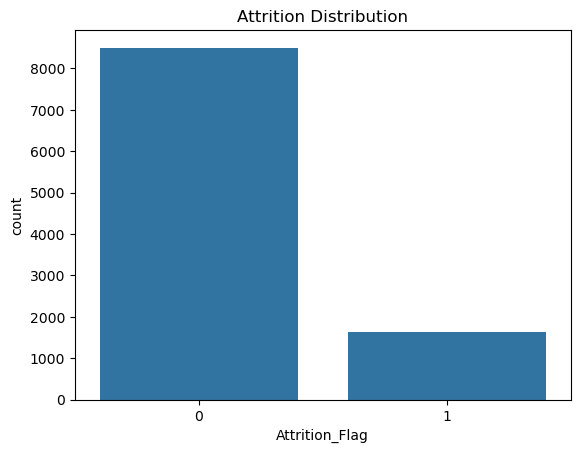

In [35]:
sns.countplot(x='Attrition_Flag', data=df)
plt.title("Attrition Distribution")
plt.show()

# The number of customers who staying > the number who left

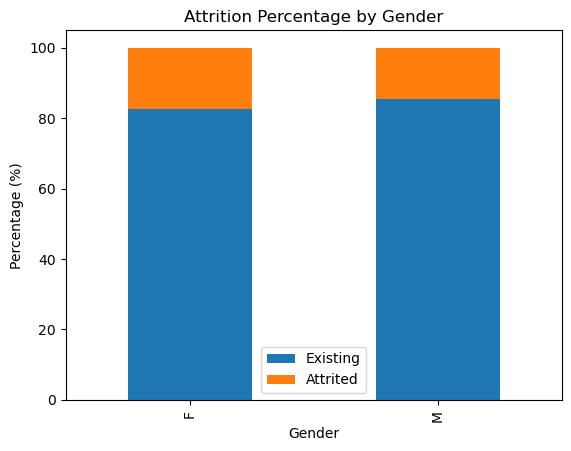

In [ ]:
gender_attrition = pd.crosstab(df['Gender'], df['Attrition_Flag'], normalize='index') * 100


gender_attrition.plot(kind='bar', stacked=True)

plt.title("Attrition Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.legend(["Existing", "Attrited"])
plt.show()

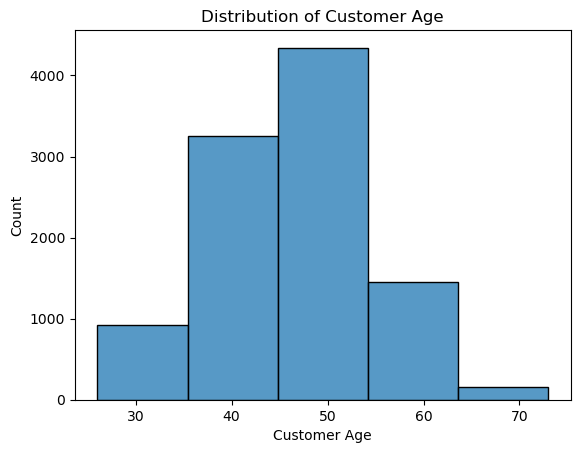

In [36]:
# Histogram
# Age Distribution
sns.histplot(df['Customer_Age'], bins=5)
plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Count")
plt.show()

# Most customers are between 35 and 50 years old.

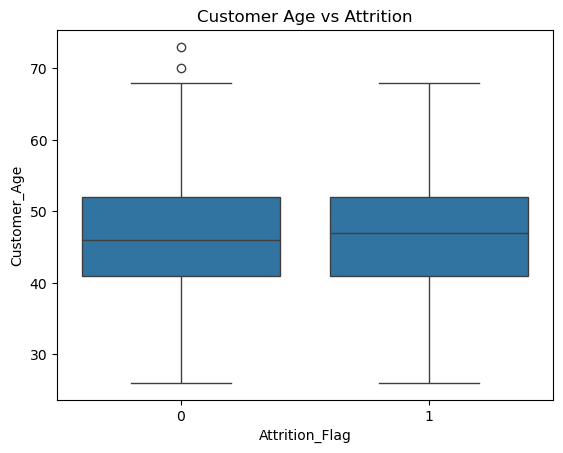

In [37]:
# Boxplot
sns.boxplot(x='Attrition_Flag', y='Customer_Age', data=df)
plt.title("Customer Age vs Attrition")
plt.show()

In [38]:
df.groupby('Attrition_Flag')['Customer_Age'].mean()

Attrition_Flag
0    46.262118
1    46.659496
Name: Customer_Age, dtype: float64

# Customer age does not show a significant difference between existing and attrited customers. 
# Both groups have similar age distributions.

In [39]:
df['Income_Category'].value_counts()

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

In [40]:
pd.crosstab(df['Income_Category'],df['Attrition_Flag'], normalize='index')*100

Attrition_Flag,0,1
Income_Category,,
$120K +,82.668501,17.331499
$40K - $60K,84.860335,15.139665
$60K - $80K,86.519258,13.480742
$80K - $120K,84.234528,15.765472
Less than $40K,82.813816,17.186184
Unknown,83.183453,16.816547


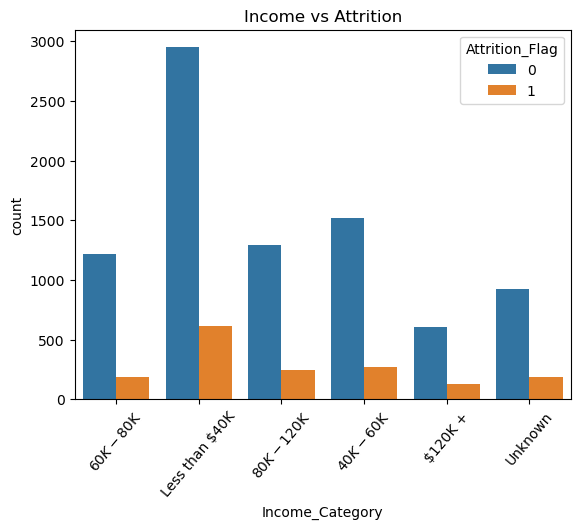

In [41]:
# Income Category vs Attrition
sns.countplot(x='Income_Category', hue='Attrition_Flag', data=df)
plt.xticks(rotation=50)
plt.title("Income vs Attrition")
plt.show()

# Customers with lower income categories tend to show higher attrition ...

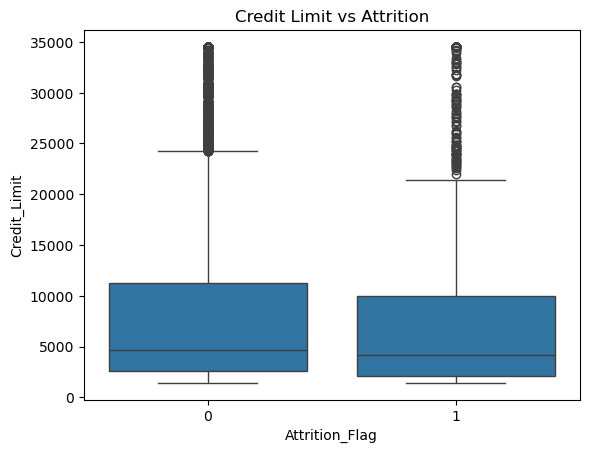

In [42]:
# Credit Limit vs Attrition
sns.boxplot(x='Attrition_Flag', y='Credit_Limit', data=df)
plt.title("Credit Limit vs Attrition")
plt.show()

# Customers with lower credit limits are more likely to leave the bank than those with higher limits.

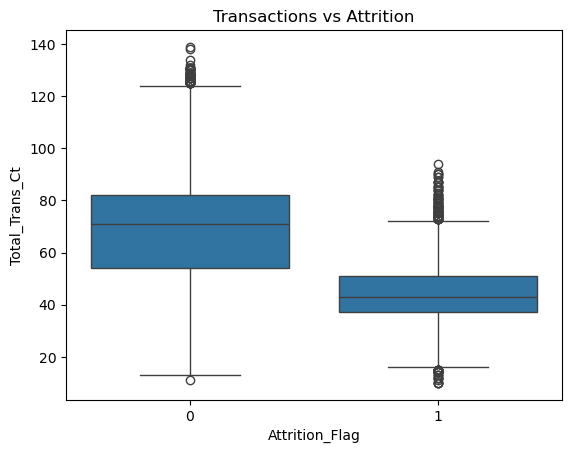

In [43]:
# Total Transactions vs Attrition
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Ct', data=df)
plt.title("Transactions vs Attrition")
plt.show()

In [44]:
df.groupby('Attrition_Flag')['Total_Trans_Ct'].mean()

Attrition_Flag
0    68.672588
1    44.933620
Name: Total_Trans_Ct, dtype: float64


# Customers who churned tend to have significantly lower transaction counts compared to active customers.


In [47]:
num_df = df.select_dtypes(include=['int64', 'float64'])

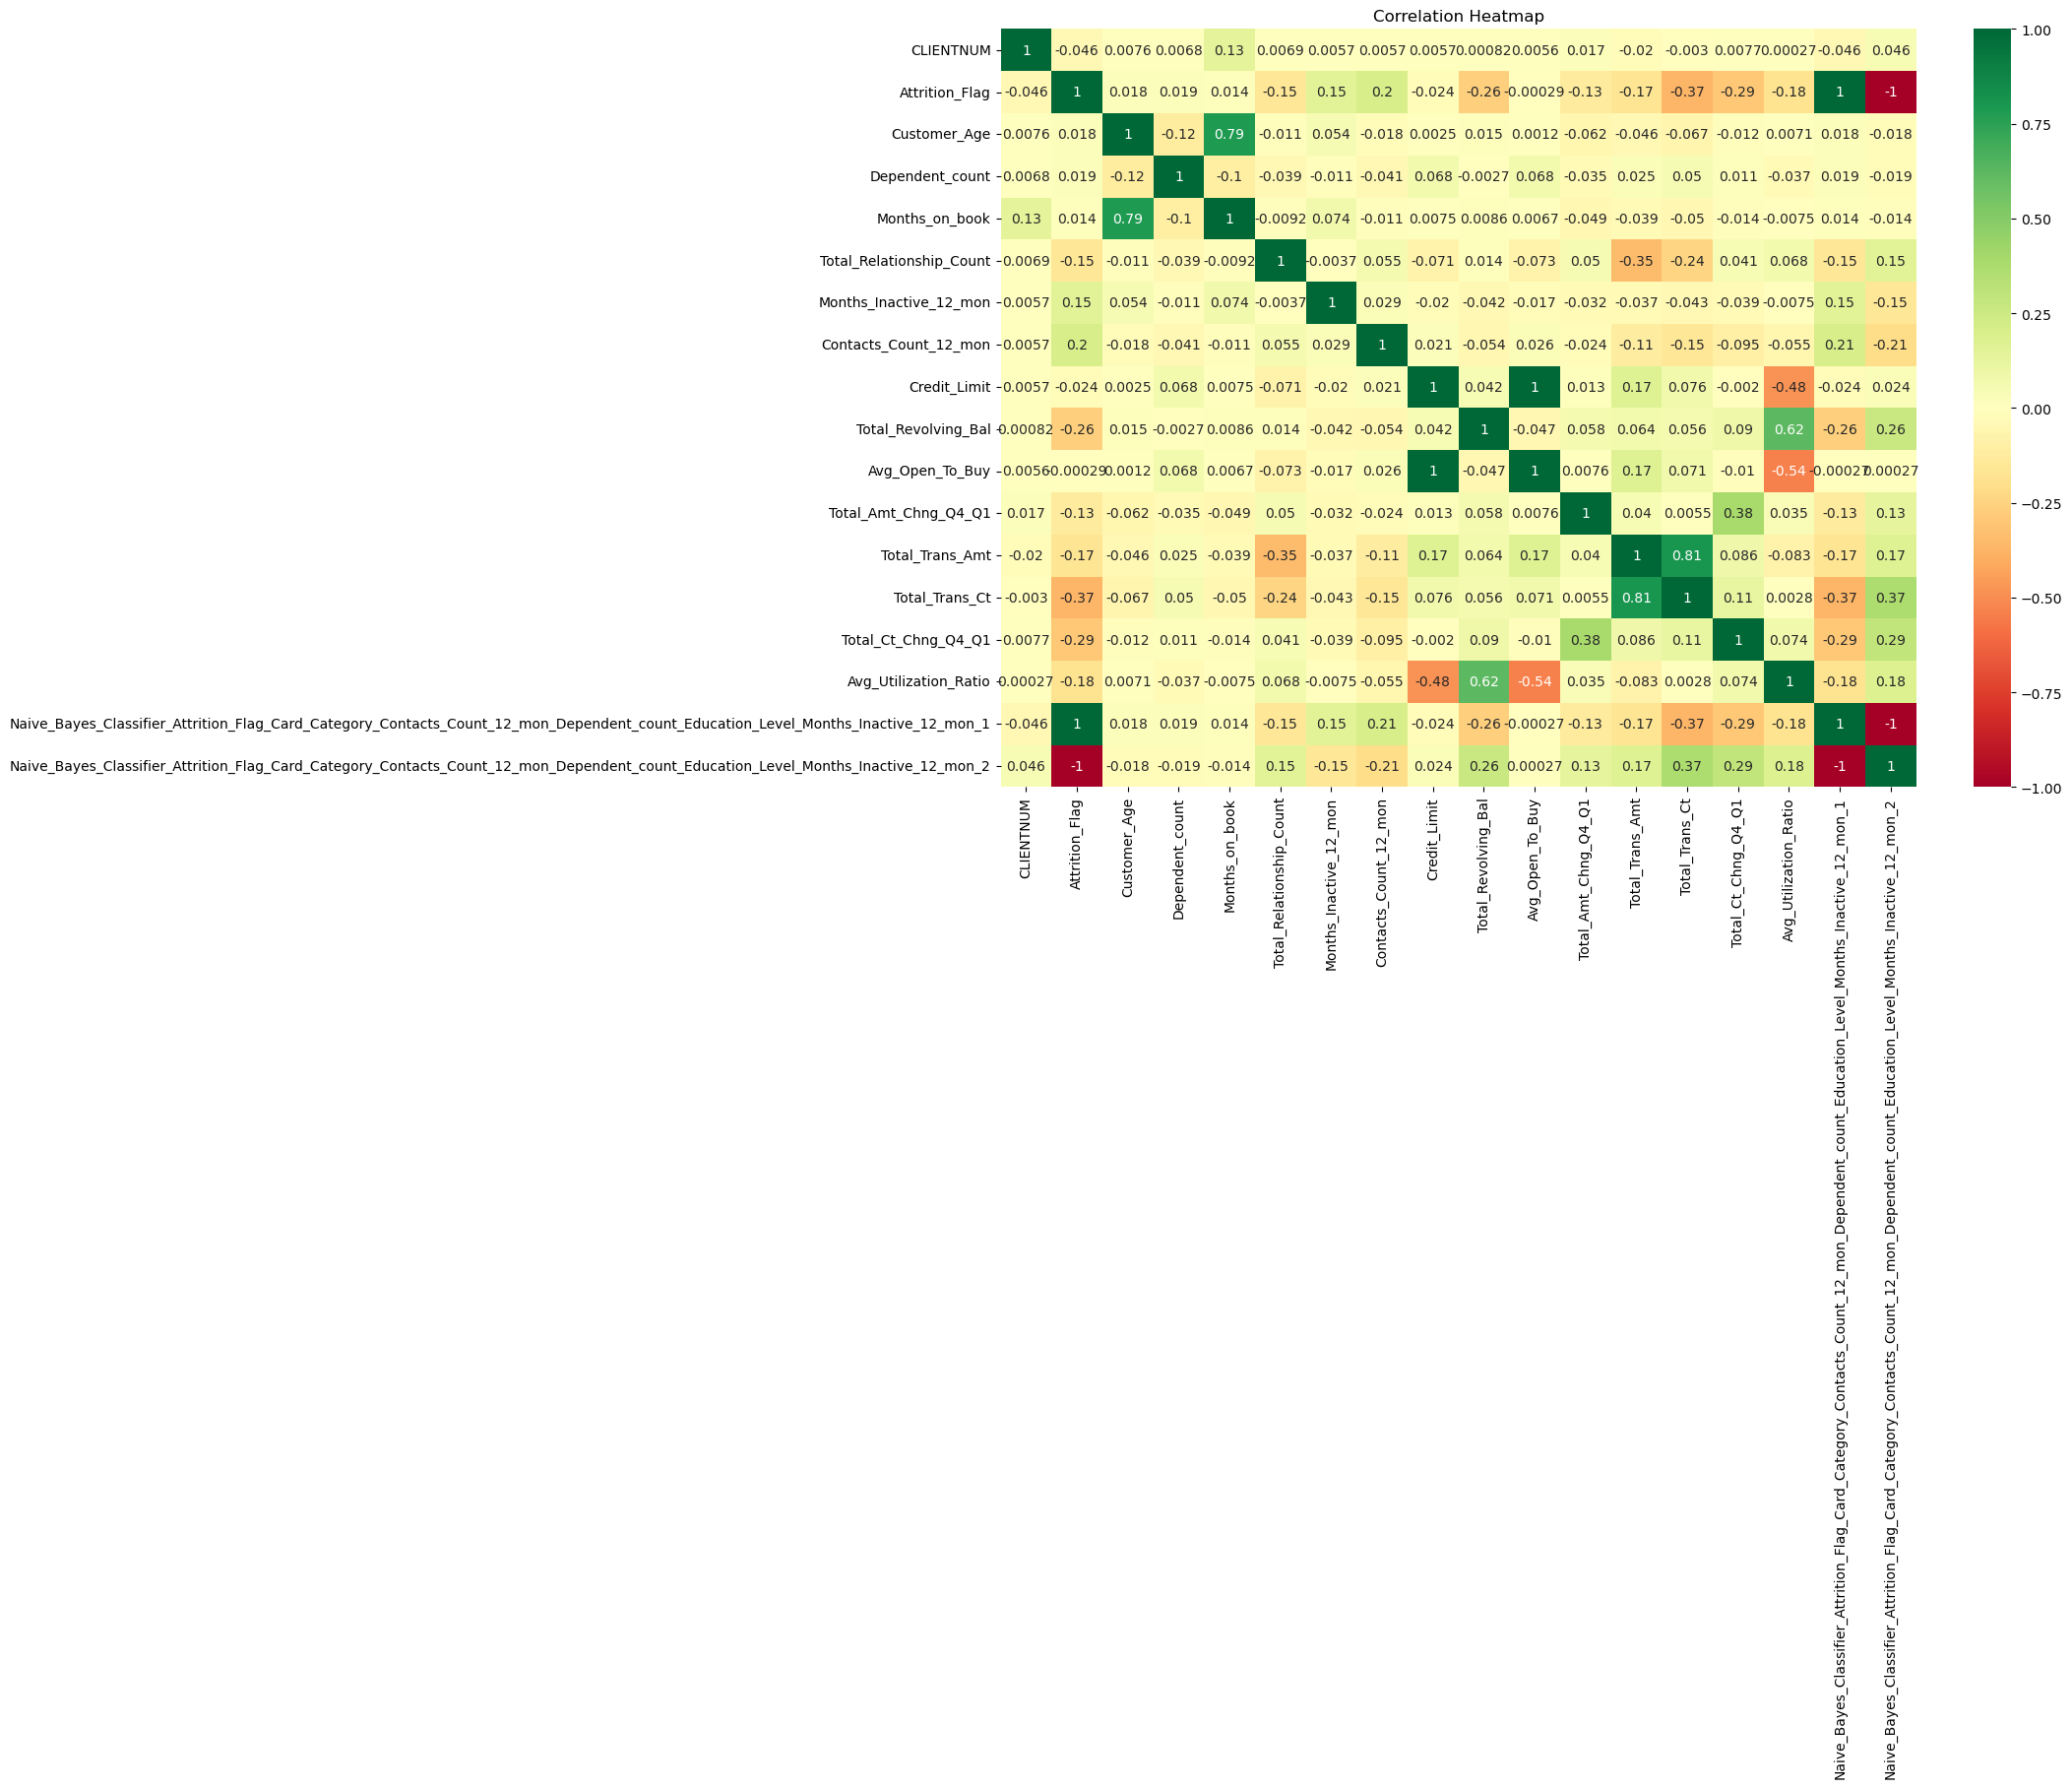

In [46]:
plt.figure(figsize=(15,10))
sns.heatmap(num_df.corr(), annot=True, cmap='RdYlGn')
plt.title("Correlation Heatmap")
plt.show()

Less active customers (fewer transactions + higher inactivity) are more likely to leave the bank.


# Recommendations

# 1. Target Low Activity Customers
Focus on customers with low transaction counts
* Send personalized offers
* Use notifications
* Provide incentives to increase usage
# 2. Improve Customer Engagement
Increase interaction with customers
* Loyalty programs
* Cashback offers
* Discounts and rewards
---
# 3. Focus on Low-Income Customers
Provide suitable plans for lower-income segments
* Lower fees
* Flexible payment options
---
# 4. Build a Churn Prediction Model
Use behavioral data (especially transaction activity)
* Identify high-risk customers early
* Take proactive actions
---
# 5. Monitor Inactive Customers
Track inactivity duration
* Re-engagement campaigns
* Special retention offers